# MNIST Model Accuracy Plots

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
import warnings
from torcheval.metrics import MulticlassAccuracy
from torchvision import datasets, transforms
import seaborn as sns
from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
import string
import seaborn as sns
import csv
from learningdynamics.koopman_inference import inference_with_koopman

In [ ]:
with open('mnist_accuracies.csv', newline='') as file:
    reader = csv.DictReader(file, fieldnames=('Layer', 'Trajectories', 'Delay', 'Accuracy'))
    accuracy_dict = {}
    for i,row in enumerate(reader):
        if i==0: 
            continue
        layer = int(row['Layer'])
        traj = int(row['Trajectories'])
        delay = int(row['Delay'])
        accuracy = float(row['Accuracy'])
        
        if layer not in accuracy_dict:
            accuracy_dict[layer] = {}
        if traj not in accuracy_dict[layer]:
            accuracy_dict[layer][traj] = {}
        
        accuracy_dict[layer][traj][delay] = accuracy

In [ ]:
# Example values for NUM_TRAJECTORIES and NUM_DELAYS
NUM_TRAJECTORIES_LIST = [1, 10, 50, 500]
NUM_DELAYS_LIST = list(range(1,11))
BASELINE_ACCURACY = 0.9720

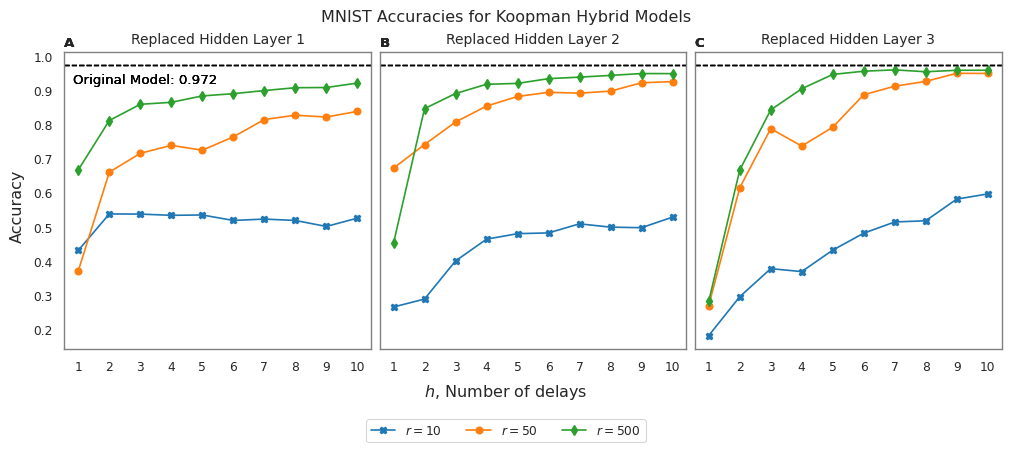

In [ ]:
# Set context
sns.set_context("paper")
sns.set_style("white")
LAYER_STARTS = [1,3,5]
markers = ['X', 'o', 'd', 's']  # Circle, Square, Diamond, X


# Create a figure and axis
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(10, 4), sharex=True, sharey=True, constrained_layout=True)
keys = list(string.ascii_uppercase[:4])


TRAJ_LIST = [10, 50, 500]
for i, layer in enumerate(LAYER_STARTS):
    for j, traj in enumerate(TRAJ_LIST):
        accuracy_list = list(accuracy_dict[layer][traj].values())
        axs[i].plot(NUM_DELAYS_LIST, accuracy_list, markers[j], linestyle="solid", label=f"$r={traj}$")
        axs[i].set_title(f'Replaced Hidden Layer {(layer+1)//2}', fontsize=10)
        
        axs[i].axhline(y=BASELINE_ACCURACY, color='black', linestyle='--', linewidth=1)
        axs[i].text(0.00, 1.02, keys[i], transform=axs[i].transAxes, weight='bold')

        axs[i].set_xticks(NUM_DELAYS_LIST)

        if i == 0: 
            # Annotate the baseline
            axs[i].annotate(f"Original Model: {BASELINE_ACCURACY}", 
                        xy=(NUM_DELAYS_LIST[-1], BASELINE_ACCURACY), 
                        xycoords='data',
                        textcoords="offset points", 
                        xytext=(-205, -13),  # Adjust offset to position the text
                        ha='left', 
                        color='black',
            )

        # Make the edges of the plot box light gray
        for spine in axs[i].spines.values():
            spine.set_color('gray')


# plt.subplots_adjust(wspace=0.05, hspace=0.1)  # Modify these values to control spacing

# Add figure title
fig.suptitle(f'MNIST Accuracies for Koopman Hybrid Models')

# Add axis labels
fig.supxlabel("$h$, Number of delays")
fig.supylabel("Accuracy")


# Automatically add a global legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), fancybox=True, ncol=len(TRAJ_LIST))

plt.savefig(f'mnist_accuracies.pdf', format='pdf', bbox_inches='tight', pad_inches=0)

